<a href="https://colab.research.google.com/github/muhamadrifkyardiansyah919-cell/metode-statistika/blob/main/ARW.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
saham <- read.csv("https://github.com/muhamadrifkyardiansyah919-cell/metode-statistika/raw/refs/heads/main/Analisis_ARIMA_Saham_TLKM_2021_2026%20(4).csv")

In [ ]:
head(saham)
str(saham)

,DATA.HISTORIS.HARGA.PENUTUPAN.MINGGUAN.SAHAM.PT.TELKOM.INDONESIA..PERSERO..TBK..TLKM.JK.,X,X.1,X.2,X.3,X.4,X.5,X.6
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,Periode: 1 Oktober 2021 s.d. 1 Oktober 2026 | Frekuensi: Mingguan (Weekly Close),,,,,,,
2,,,,,,,,
3,No,Tanggal,Open,High,Low,Close,Adj Close,Volume
4,1,"Oct 01, 2021","3,817.17","3,844.75","3,745.80","3,810.96","2,858.22","403,046,582"
5,2,"Oct 08, 2021","3,811.62","3,814.73","3,769.15","3,814.73","2,861.05","254,549,131"
6,3,"Oct 15, 2021","3,936.39","3,968.28","3,866.83","3,968.28","2,976.21","814,989,791"


'data.frame':	265 obs. of  8 variables:
 $ DATA.HISTORIS.HARGA.PENUTUPAN.MINGGUAN.SAHAM.PT.TELKOM.INDONESIA..PERSERO..TBK..TLKM.JK.: chr  "Periode: 1 Oktober 2021 s.d. 1 Oktober 2026 | Frekuensi: Mingguan (Weekly Close)" "" "No" "1" ...
 $ X                                                                                       : chr  "" "" "Tanggal" "Oct 01, 2021" ...
 $ X.1                                                                                     : chr  "" "" "Open" "3,817.17" ...
 $ X.2                                                                                     : chr  "" "" "High" "3,844.75" ...
 $ X.3                                                                                     : chr  "" "" "Low" "3,745.80" ...
 $ X.4                                                                                     : chr  "" "" "Close" "3,810.96" ...
 $ X.5                                                                                     : chr  "" "" "Adj Close" "2,858.22"

In [ ]:
# Membaca data dengan melompati 3 baris teratas
saham_clean <- read.csv("https://github.com/muhamadrifkyardiansyah919-cell/metode-statistika/raw/refs/heads/main/Analisis_ARIMA_Saham_TLKM_2021_2026%20(4).csv", skip = 3, header = FALSE)

# Berikan nama kolom secara manual
colnames(saham_clean) <- c("No", "Tanggal", "Open", "High", "Low", "Close", "Adj_Close", "Volume")

# Bersihkan koma dan konversi kolom Close ke numerik
saham_clean$Close <- as.numeric(gsub(",", "", saham_clean$Close))

# Hapus baris yang bernilai NA secara otomatis
saham_clean <- na.omit(saham_clean)

# Membuat objek Time Series
harga_close <- ts(saham_clean$Close, frequency = 52)
print(head(harga_close))

Warning message:
“NAs introduced by coercion”


Time Series:
Start = c(1, 1) 
End = c(1, 6) 
Frequency = 52 
[1] 3810.96 3814.73 3968.28 4093.92 4103.16 4098.53


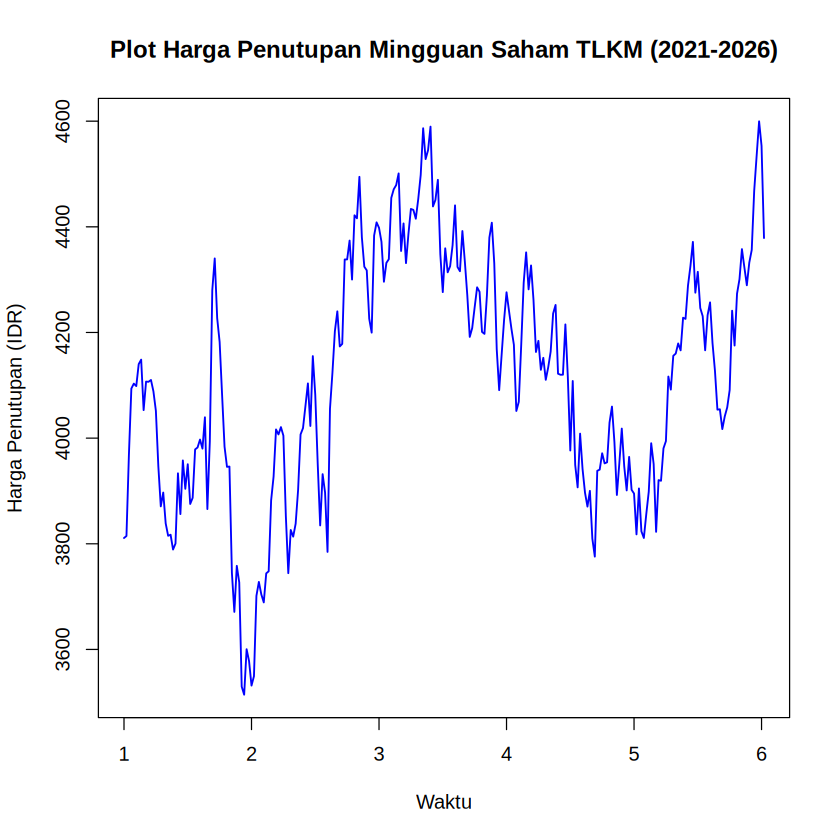

In [ ]:
plot(harga_close, main = "Plot Harga Penutupan Mingguan Saham TLKM (2021-2026)",
     ylab = "Harga Penutupan (IDR)", xlab = "Waktu", col = "blue", lwd = 1.5)

In [ ]:
if (!require("tseries")) install.packages("tseries", repos = "http://cran.us.r-project.org")
library(tseries)

# Lakukan uji Augmented Dickey-Fuller (ADF)
adf.test(harga_close)

Loading required package: tseries

Warning message in library(package, lib.loc = lib.loc, character.only = TRUE, logical.return = TRUE, :
“there is no package called ‘tseries’”
Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘xts’, ‘TTR’, ‘quadprog’, ‘zoo’, ‘quantmod’


Registered S3 method overwritten by 'quantmod':
  method            from
  as.zoo.data.frame zoo 




	Augmented Dickey-Fuller Test

data:  harga_close
Dickey-Fuller = -2.2415, Lag order = 6, p-value = 0.4742
alternative hypothesis: stationary


In [ ]:
harga_diff <- diff(harga_close, differences = 1)

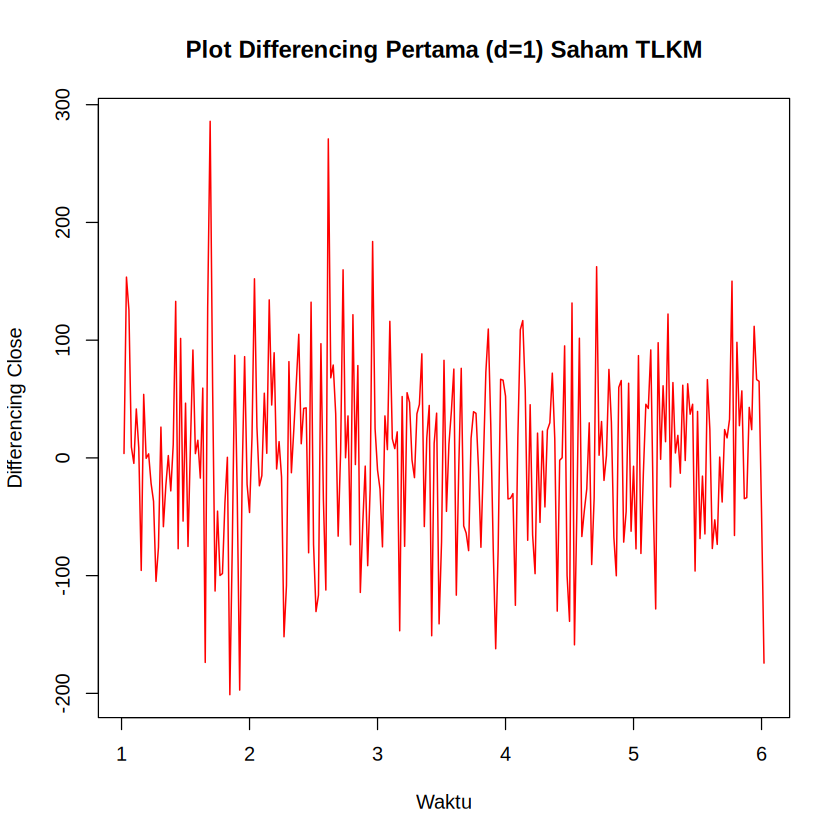

In [ ]:
plot(harga_diff, main = "Plot Differencing Pertama (d=1) Saham TLKM",
     ylab = "Differencing Close", xlab = "Waktu", col = "red", lwd = 1.2)

In [ ]:
adf.test(harga_diff)

Warning message in adf.test(harga_diff):
“p-value smaller than printed p-value”



	Augmented Dickey-Fuller Test

data:  harga_diff
Dickey-Fuller = -6.2177, Lag order = 6, p-value = 0.01
alternative hypothesis: stationary


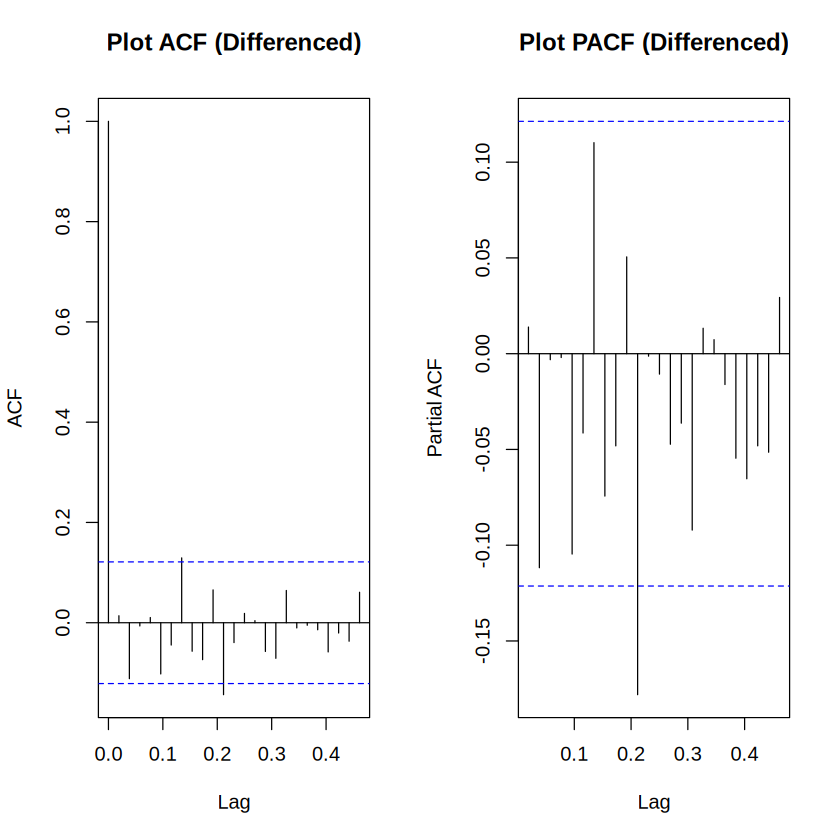

In [ ]:
par(mfrow=c(1,2))
acf(harga_diff, main="Plot ACF (Differenced)")
pacf(harga_diff, main="Plot PACF (Differenced)")
par(mfrow=c(1,1))

In [ ]:
if (!require("forecast")) install.packages("forecast", repos = "http://cran.us.r-project.org")
library(forecast)

model_auto <- auto.arima(harga_close, stepwise = FALSE, approximation = FALSE)
summary(model_auto)

Loading required package: forecast

Warning message in library(package, lib.loc = lib.loc, character.only = TRUE, logical.return = TRUE, :
“there is no package called ‘forecast’”
Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘colorspace’, ‘fracdiff’, ‘lmtest’, ‘timeDate’, ‘urca’, ‘RcppArmadillo’




Series: harga_close 
ARIMA(0,1,0) 

sigma^2 = 6044:  log likelihood = -1506.58
AIC=3015.15   AICc=3015.17   BIC=3018.72

Training set error measures:
                   ME    RMSE      MAE        MPE     MAPE      MASE       ACF1
Training set 2.181912 77.5932 60.85329 0.03523066 1.486446 0.2009544 0.01389914


	Ljung-Box test

data:  Residuals from ARIMA(0,1,0)
Q* = 67.988, df = 52, p-value = 0.06749

Model df: 0.   Total lags used: 52



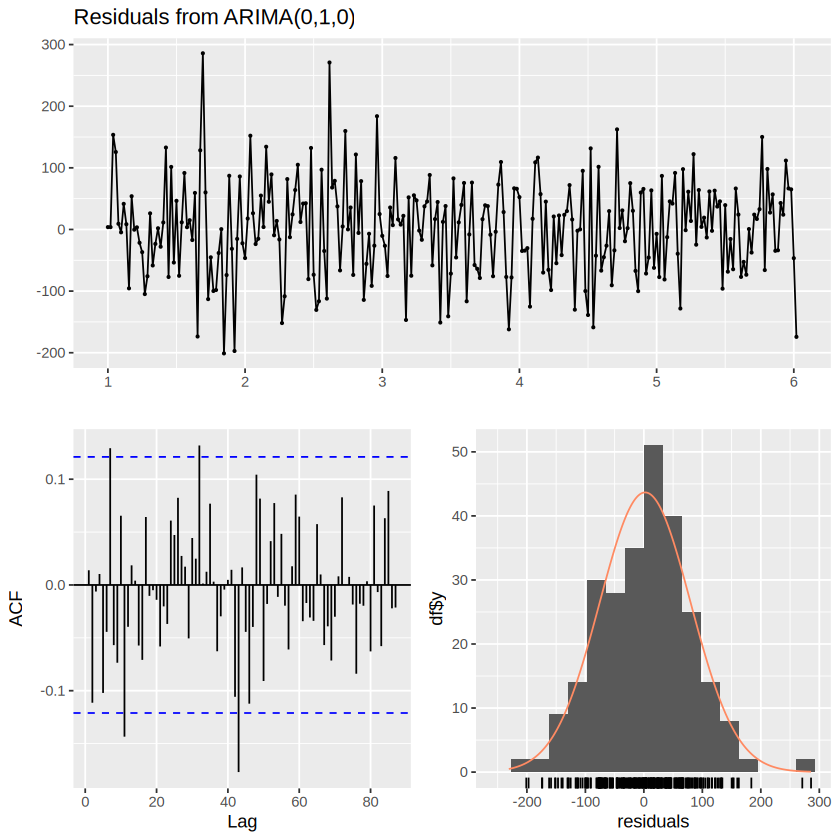

In [ ]:
checkresiduals(model_auto)

In [ ]:
ramalan <- forecast(model_auto, h = 12)
print(ramalan)

         Point Forecast    Lo 80    Hi 80    Lo 95    Hi 95
6.038462        4378.81 4279.180 4478.440 4226.439 4531.181
6.057692        4378.81 4237.912 4519.708 4163.325 4594.295
6.076923        4378.81 4206.246 4551.374 4114.896 4642.724
6.096154        4378.81 4179.550 4578.070 4074.068 4683.552
6.115385        4378.81 4156.031 4601.589 4038.098 4719.522
6.134615        4378.81 4134.767 4622.853 4005.579 4752.041
6.153846        4378.81 4115.214 4642.406 3975.674 4781.946
6.173077        4378.81 4097.014 4660.606 3947.840 4809.780
6.192308        4378.81 4079.920 4677.700 3921.697 4835.923
6.211538        4378.81 4063.752 4693.868 3896.971 4860.649
6.230769        4378.81 4048.375 4709.245 3873.453 4884.167
6.250000        4378.81 4033.682 4723.938 3850.982 4906.638


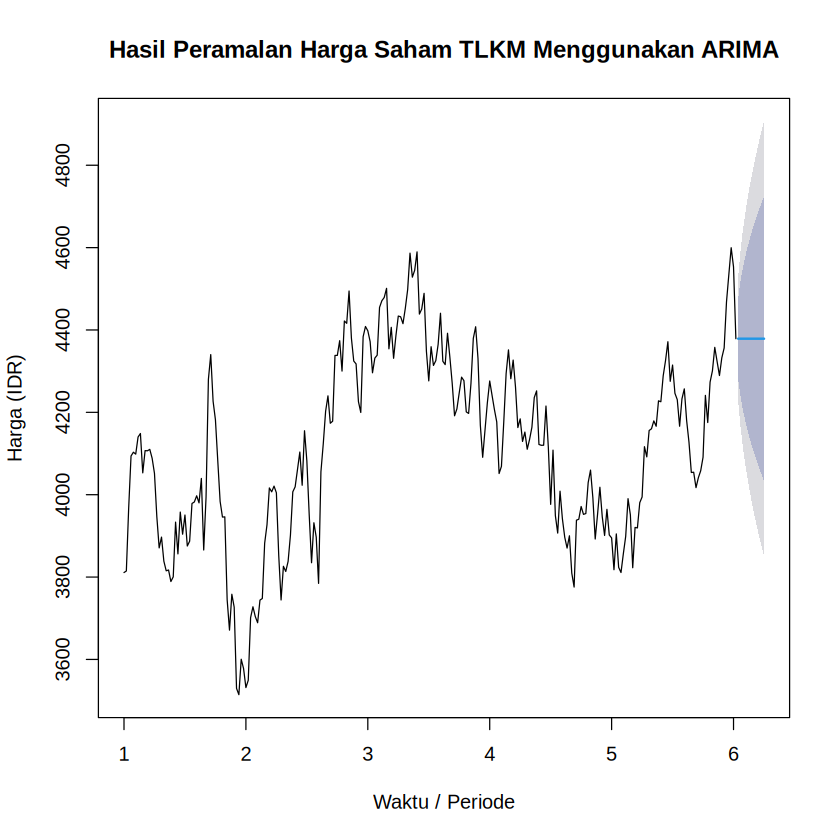

In [ ]:
plot(ramalan, main = "Hasil Peramalan Harga Saham TLKM Menggunakan ARIMA",
     ylab = "Harga (IDR)", xlab = "Waktu / Periode")

In [ ]:
# Gunakan data saham_clean yang sudah memiliki kolom yang benar
saham_clean$Tanggal <- as.Date(saham_clean$Tanggal, format="%b %d, %Y")
saham_clean <- saham_clean[order(saham_clean$Tanggal), ]

# Buat kembali objek Time Series dari data yang berurutan
data_ts <- ts(saham_clean$Close, frequency = 52)
print(head(data_ts))

Time Series:
Start = c(1, 1) 
End = c(1, 6) 
Frequency = 52 
[1] 3810.96 3814.73 3968.28 4093.92 4103.16 4098.53


=== STATISTIK DESKRIPTIF HARGA SAHAM TLKM ===
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   3514    3946    4118    4112    4296    4600 
Standar Deviasi : 230.4526 
Varians         : 53108.4 


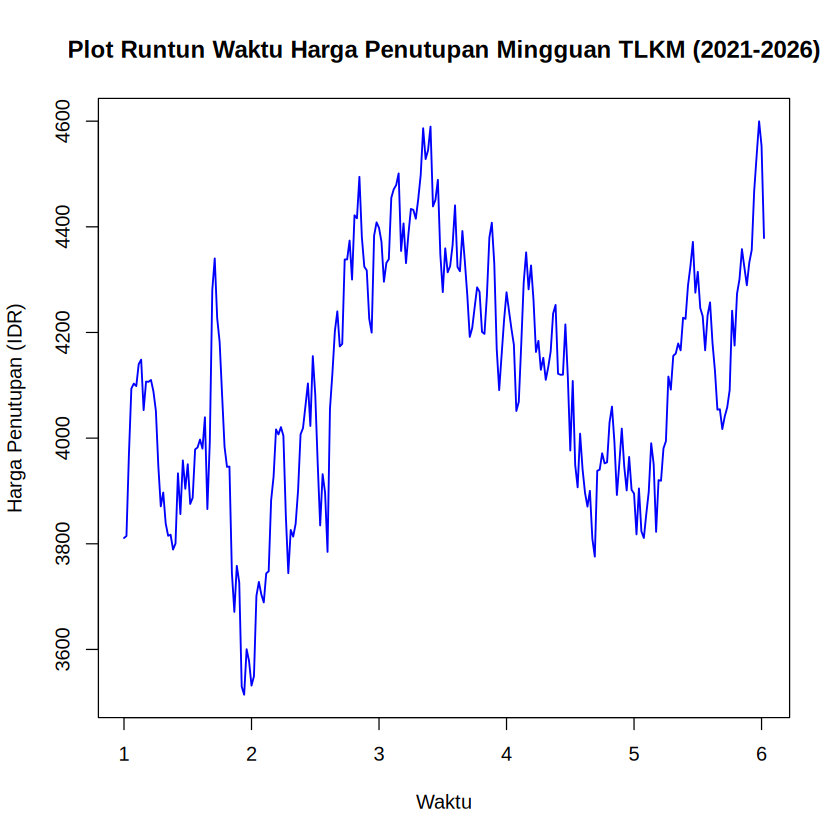

In [ ]:
cat("=== STATISTIK DESKRIPTIF HARGA SAHAM TLKM ===\n")
print(summary(saham_clean$Close))
cat("Standar Deviasi :", sd(saham_clean$Close), "\n")
cat("Varians         :", var(saham_clean$Close), "\n")
plot(data_ts, main = "Plot Runtun Waktu Harga Penutupan Mingguan TLKM (2021-2026)",
     ylab = "Harga Penutupan (IDR)", xlab = "Waktu", col = "blue", lwd = 1.5)

In [ ]:
n <- length(data_ts)
n_train <- round(0.8 * n)

train_data <- window(data_ts, end = c(start(data_ts)[1] + (n_train-1)/52))
test_data <- window(data_ts, start = c(start(data_ts)[1] + n_train/52))

cat("Jumlah total data  :", n, "\n")
cat("Jumlah data training:", length(train_data), "\n")
cat("Jumlah data testing :", length(test_data), "\n")

Jumlah total data  : 262 
Jumlah data training: 210 
Jumlah data testing : 52 


In [ ]:
model_1 <- Arima(train_data, order = c(1,1,1))
model_2 <- Arima(train_data, order = c(2,1,2))
model_3 <- auto.arima(train_data, stepwise = FALSE, approximation = FALSE)
tabel_perbandingan <- data.frame(
  Model = c("ARIMA(1,1,1)", "ARIMA(2,1,2)", "Auto ARIMA (Terbaik)"),
  AIC = c(AIC(model_1), AIC(model_2), AIC(model_3)),
  BIC = c(BIC(model_1), BIC(model_2), BIC(model_3))
)

cat("=== TABEL PERBANDINGAN MODEL ARIMA ===\n")
print(tabel_perbandingan)
model_terbaik <- model_3
summary(model_terbaik)

=== TABEL PERBANDINGAN MODEL ARIMA ===
                 Model      AIC      BIC
1         ARIMA(1,1,1) 2429.196 2439.223
2         ARIMA(2,1,2) 2428.350 2445.061
3 Auto ARIMA (Terbaik) 2426.406 2436.433


Series: train_data 
ARIMA(0,1,2) 

Coefficients:
         ma1      ma2
      0.0326  -0.1683
s.e.  0.0688   0.0710

sigma^2 = 6326:  log likelihood = -1210.2
AIC=2426.41   AICc=2426.52   BIC=2436.43

Training set error measures:
                    ME     RMSE      MAE         MPE    MAPE      MASE
Training set 0.1058841 78.96346 62.36943 -0.01875661 1.52851 0.1975209
                    ACF1
Training set 0.001396709

In [ ]:
h_test <- length(test_data)
forecast_test <- forecast(model_terbaik, h = h_test)
evaluasi_akurasi <- accuracy(forecast_test, test_data)
cat("=== EVALUASI AKURASI MODEL (TRAIN vs TEST) ===\n")
print(evaluasi_akurasi)

=== EVALUASI AKURASI MODEL (TRAIN vs TEST) ===
                      ME      RMSE       MAE         MPE     MAPE      MASE
Training set   0.1058841  78.96346  62.36943 -0.01875661 1.528510 0.1975209
Test set     338.6074561 388.20901 339.77655  7.93302752 7.963665 1.0760554
                    ACF1 Theil's U
Training set 0.001396709        NA
Test set     0.911479899  5.739604


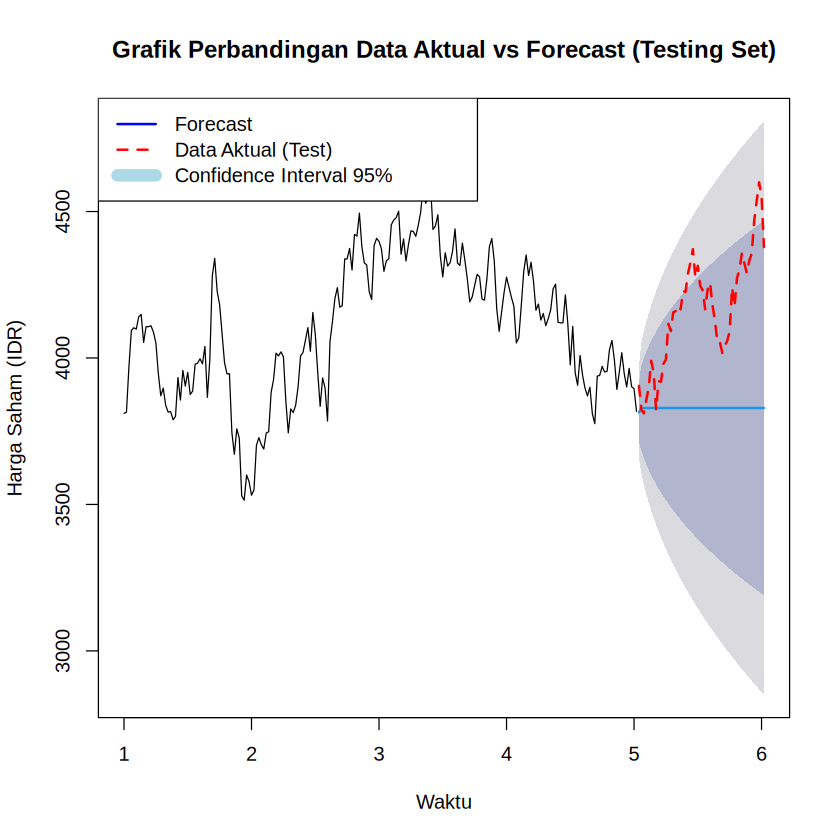

In [ ]:
plot(forecast_test, main = "Grafik Perbandingan Data Aktual vs Forecast (Testing Set)",
     ylab = "Harga Saham (IDR)", xlab = "Waktu")
lines(test_data, col = "red", lty = 2, lwd = 2)
legend("topleft", legend = c("Forecast", "Data Aktual (Test)", "Confidence Interval 95%"),
       col = c("blue", "red", "lightblue"), lty = c(1, 2, 1), lwd = c(2, 2, 10))

Series: data_ts 
ARIMA(0,1,0) 

sigma^2 = 6044:  log likelihood = -1506.58
AIC=3015.15   AICc=3015.17   BIC=3018.72

Training set error measures:
                   ME    RMSE      MAE        MPE     MAPE      MASE       ACF1
Training set 2.181912 77.5932 60.85329 0.03523066 1.486446 0.2009544 0.01389914

=== HASIL FINAL FORECAST 12 MINGGU KE DEPAN ===
         Point Forecast    Lo 80    Hi 80    Lo 95    Hi 95
6.038462        4378.81 4279.180 4478.440 4226.439 4531.181
6.057692        4378.81 4237.912 4519.708 4163.325 4594.295
6.076923        4378.81 4206.246 4551.374 4114.896 4642.724
6.096154        4378.81 4179.550 4578.070 4074.068 4683.552
6.115385        4378.81 4156.031 4601.589 4038.098 4719.522
6.134615        4378.81 4134.767 4622.853 4005.579 4752.041
6.153846        4378.81 4115.214 4642.406 3975.674 4781.946
6.173077        4378.81 4097.014 4660.606 3947.840 4809.780
6.192308        4378.81 4079.920 4677.700 3921.697 4835.923
6.211538        4378.81 4063.752 4693.868 3896.971 4860.649
6.230769        4378.81 4048.375 4709.245 3873.453 4884.167
6.250000        4378.81 4033.682 4723.938 3850.982 4906.638


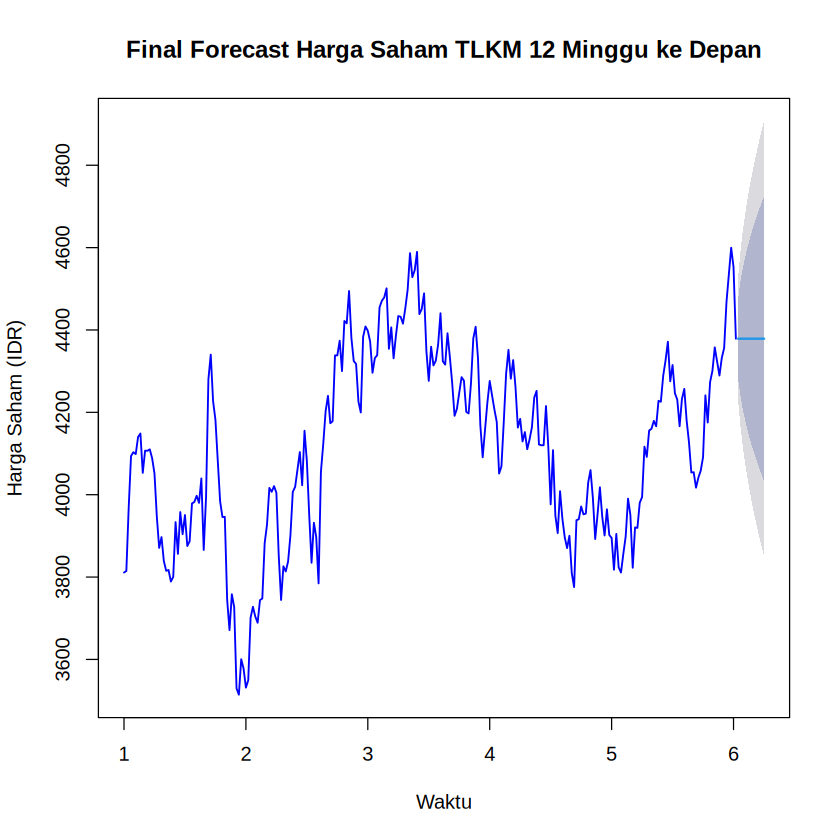

In [ ]:
model_final <- auto.arima(data_ts, stepwise = FALSE, approximation = FALSE)
summary(model_final)
horizon_masa_depan <- 12
final_forecast <- forecast(model_final, h = horizon_masa_depan)

cat("=== HASIL FINAL FORECAST 12 MINGGU KE DEPAN ===\n")
print(final_forecast)
plot(final_forecast, main = "Final Forecast Harga Saham TLKM 12 Minggu ke Depan",
     ylab = "Harga Saham (IDR)", xlab = "Waktu", col = "blue", lwd = 1.5)